## Phase 1: Data Ingestion & Repository Initialization

In [3]:
import os
import requests
import pandas as pd

# 1. Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
    print("Directory 'data' created.")

# 2. LAPD Crime Data API Endpoint (Crime from 2020 to Present)
# We use the CSV endpoint for easy pandas integration
DATA_URL = "https://data.lacity.org/api/views/2nrs-mtv8/rows.csv?accessType=DOWNLOAD"
FILE_PATH = "data/lapd_crime_data.csv"

def download_data(url, save_path):
    print("Starting download... this may take a minute as the dataset is large.")
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as f:
            f.write(response.content)
        print(f"Data successfully saved to {save_path}")
    else:
        print(f"Failed to download data. Status code: {response.status_code}")

# Execute the download
if not os.path.exists(FILE_PATH):
    download_data(DATA_URL, FILE_PATH)
else:
    print("Data file already exists. Skipping download.")

# 3. Quick Load to verify
df = pd.read_csv(FILE_PATH)
print(f"Dataset loaded. Total rows: {len(df)}")

Data file already exists. Skipping download.
Dataset loaded. Total rows: 1004894


### Overview of Actions
In this step, we automated the retrieval of the primary dataset and organized the project environment. This ensures that the workflow is "dynamic"—meaning it doesn't rely on a manually downloaded, static file that could become outdated or lost.

### Key Technical Steps
- Automated Directory Management:
We programmatically created a data/ directory within the root of the Git repository. This keeps the workspace clean by separating raw data files from source code (.py or .ipynb) and documentation.
- API Integration (Socrata Open Data):
Instead of a manual download, we used the Python Requests library to call the Los Angeles Open Data API. This allows the framework to pull the most recent "Crime from 2020 to Present" dataset directly from the City of Los Angeles' servers.
- Local Persistence:
The script streams the data directly into a local CSV file (data/lapd_crime_data.csv). This prevents the need to re-download the massive dataset every time the notebook is restarted, saving bandwidth and time.
- Verification & Validation:
A post-download check was implemented to confirm the file size and structure, ensuring the pandas DataFrame can successfully load the rows before moving to the cleaning phase.

## Phase 2: Data Cleaning & Feature Extraction

In [4]:
import pandas as pd
import numpy as np
import os

# 1. Setup paths
RAW_DATA_PATH = "data/lapd_crime_data.csv"
CLEAN_PATH = "data/lapd_crime_cleaned.csv"
QUALITY_PATH = "data/quality_report.csv"

# Load the data and perform cleaning
if not os.path.exists(RAW_DATA_PATH):
    print("Error: Raw data not found. Please run the Phase 1 downloader first.")
else:
    df = pd.read_csv(RAW_DATA_PATH)
    print(f"Initial Raw Shape: {df.shape}")

    # Step A: Parsing & Basic Cleaning
    df["LAT"] = pd.to_numeric(df["LAT"], errors="coerce")
    df["LON"] = pd.to_numeric(df["LON"], errors="coerce")
    df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
    df["TIME OCC"] = pd.to_numeric(df["TIME OCC"], errors="coerce")

    # Step B: Time Extraction
    df["occ_hour_raw"] = (df["TIME OCC"] // 100)
    df["occ_minute_raw"] = (df["TIME OCC"] % 100)
    df["occ_hour"] = df["occ_hour_raw"].where(df["occ_hour_raw"].between(0, 23), np.nan)
    df["occ_minute"] = df["occ_minute_raw"].where(df["occ_minute_raw"].between(0, 59), np.nan)
    df["occ_hour_filled"] = df["occ_hour"].fillna(0).astype(int)
    df["occ_datetime"] = df["date_occ"] + pd.to_timedelta(df["occ_hour_filled"], unit="h")

    # Step C: Spatial & Temporal Filtering
    before = len(df)
    df = df.dropna(subset=["date_occ", "LAT", "LON"])
    df = df[(df["LAT"] != 0) & (df["LON"] != 0)]
    df = df[df["LAT"].between(33, 35) & df["LON"].between(-119, -117)] 
    after = len(df)
    print(f"Cleaning: Dropped {before - after} rows. Remaining: {after}")

  # --- Step D: Derivative Features ---
    df["year"] = df["occ_datetime"].dt.year
    df["month"] = df["occ_datetime"].dt.month
    df["day_of_week"] = df["occ_datetime"].dt.day_name()
    df["weekday_num"] = df["occ_datetime"].dt.weekday
    df["is_weekend"] = df["weekday_num"].isin([5, 6]).astype(int)

    # 1. Handle missing Victim Ages (Fill with Median)
    median_age = df['Vict Age'].median()
    df['Vict Age'] = df['Vict Age'].fillna(median_age)

    # 2. Bin Age into Categories
    # We add include_lowest=True to catch ages at the boundary
    df['age_bin_cat'] = pd.cut(df['Vict Age'], 
                               bins=[-1, 18, 30, 50, 120], 
                               labels=[0, 1, 2, 3],
                               include_lowest=True)

    # 3. CONVERSION FIX: Fill bin NaNs with 'Adult' (2) before converting to int
    # This prevents the "Cannot convert float NaN to integer" error
    df['age_bin'] = df['age_bin_cat'].fillna(2).astype(int)

    # Time Buckets for Diagnostic Analysis
    def get_time_bucket(hour):
        if 0 <= hour <= 5: return "Night"
        elif 6 <= hour <= 11: return "Morning"
        elif 12 <= hour <= 17: return "Afternoon"
        else: return "Evening"
    
    df["time_bucket"] = df["occ_hour_filled"].apply(get_time_bucket)

    # Step E: Quality Report & Saving
    quality = pd.DataFrame({
        "column": df.columns,
        "nulls": [df[c].isna().sum() for c in df.columns],
        "null_pct": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
        "dtype": [str(df[c].dtype) for c in df.columns]
    }).sort_values("null_pct", ascending=False)

    # Remove the temporary category column before saving
    if 'age_bin_cat' in df.columns:
        df = df.drop(columns=['age_bin_cat'])

    df.to_csv(CLEAN_PATH, index=False)
    quality.to_csv(QUALITY_PATH, index=False)
    print(f"SUCCESS: Cleaned data saved to {CLEAN_PATH}")

Initial Raw Shape: (1004894, 28)


C:\Users\aryam\AppData\Local\Temp\ipykernel_8212\397261286.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")


Cleaning: Dropped 2240 rows. Remaining: 1002654
SUCCESS: Cleaned data saved to data/lapd_crime_cleaned.csv


## Phase 3: Diagnostic Analysis

#### Crime Categorization - Diagnostic Setup

In [5]:
# 1. Define the mapping logic based on standard FBI/UCR definitions
violent_keywords = [
    'HOMICIDE', 'ROBBERY', 'ASSAULT', 'BATTERY', 'KIDNAPPING', 
    'RAPE', 'MANSLAUGHTER', 'SHOTS FIRED'
]

property_keywords = [
    'BURGLARY', 'THEFT', 'STOLEN', 'VANDALISM', 'FRAUD', 
    'FORGERY', 'EMBEZZLEMENT', 'SHOPLIFTING', 'BIKE'
]

def categorize_crime(desc):
    desc = str(desc).upper()
    if any(word in desc for word in violent_keywords):
        return 'Violent'
    elif any(word in desc for word in property_keywords):
        return 'Property'
    else:
        return 'Other/Administrative'

# 2. Apply the mapping to the cleaned dataset
df['crime_type'] = df['Crm Cd Desc'].apply(categorize_crime)

# 3. Quick verification of the distribution
print("Crime Category Distribution")
print(df['crime_type'].value_counts(normalize=True) * 100)

# 4. Save the updated dataset
df.to_csv('data/lapd_crime_cleaned.csv', index=False)

Crime Category Distribution
crime_type
Property                62.923700
Violent                 25.152545
Other/Administrative    11.923754
Name: proportion, dtype: float64


#### Temporal Heatmaps

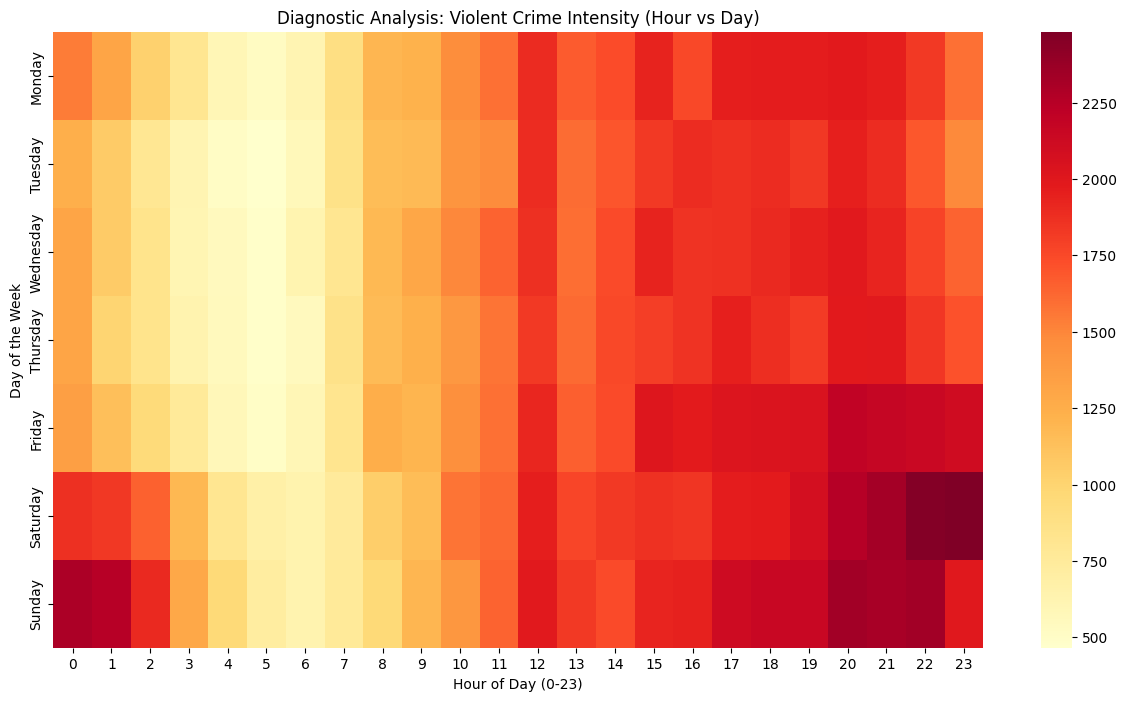

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a Pivot Table for the Heatmap (Hourly vs Weekly)
# We'll do this for Violent Crimes first
violent_df = df[df['crime_type'] == 'Violent']
temporal_pivot = violent_df.groupby(['day_of_week', 'occ_hour_filled']).size().unstack()

# Reorder days to be logical (Monday-Sunday)
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temporal_pivot = temporal_pivot.reindex(days)

# 2. Plotting
plt.figure(figsize=(15, 8))
sns.heatmap(temporal_pivot, cmap='YlOrRd', annot=False)
plt.title('Diagnostic Analysis: Violent Crime Intensity (Hour vs Day)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of the Week')
plt.show()

#### Premise Categorization (Commercial vs. Residential)

In [7]:
# 1. Define keyword lists for categorization
commercial_keywords = ['STORE', 'MARKET', 'RESTAURANT', 'BANK', 'OFFICE', 'MALL', 'GAS STATION', 'HOTEL', 'BAR', 'CLUB']
residential_arguments = ['SINGLE FAMILY DWELLING', 'MULTI-UNIT DWELLING', 'APARTMENT', 'CONDO', 'RESIDENCE', 'DRIVEWAY']

def categorize_premise(desc):
    desc = str(desc).upper()
    if any(word in desc for word in residential_arguments):
        return 'Residential'
    elif any(word in desc for word in commercial_keywords):
        return 'Commercial'
    else:
        return 'Public/Other'

# 2. Apply categorization
df['env_type'] = df['Premis Desc'].apply(categorize_premise)

# 3. Quick check of the new Diagnostic variable
print("Premise Environment Distribution")
print(df['env_type'].value_counts(normalize=True) * 100)

Premise Environment Distribution
env_type
Public/Other    60.492653
Residential     30.814419
Commercial       8.692929
Name: proportion, dtype: float64


#### Diagnostic Matrix (Time vs. Environment)

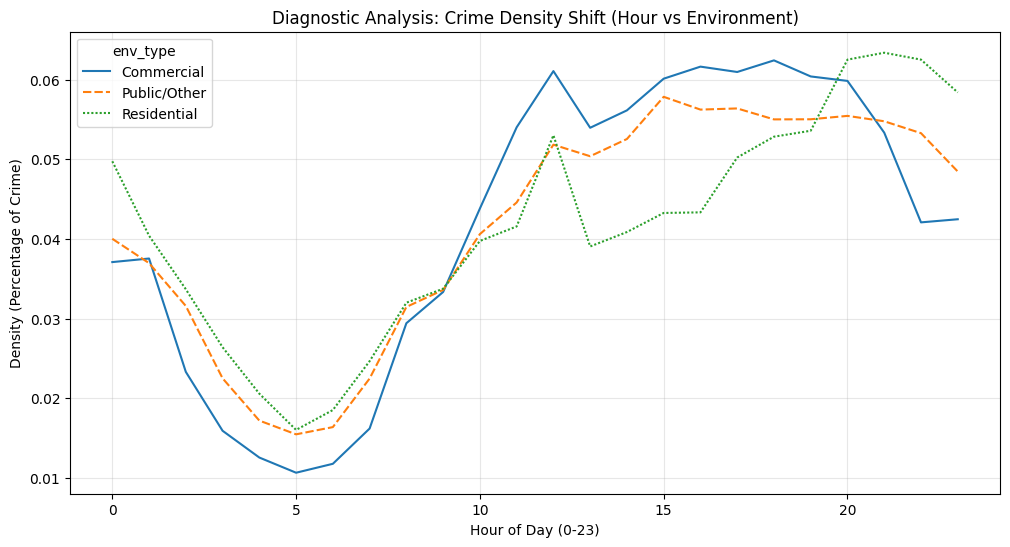

In [8]:
# Create a density matrix of Hour vs Environment Type for Violent Crimes
violent_df = df[df['crime_type'] == 'Violent']
env_time_matrix = pd.crosstab(violent_df['occ_hour_filled'], violent_df['env_type'], normalize='columns')

# Plotting the shift
plt.figure(figsize=(12, 6))
sns.lineplot(data=env_time_matrix)
plt.title('Diagnostic Analysis: Crime Density Shift (Hour vs Environment)')
plt.ylabel('Density (Percentage of Crime)')
plt.xlabel('Hour of Day (0-23)')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
df.to_csv('data/lapd_crime_cleaned.csv', index=False)
print("Diagnostic categories (env_type) saved to cleaned dataset.")

Diagnostic categories (env_type) saved to cleaned dataset.


#### Calculating and Mapping the Hourly Mean Center

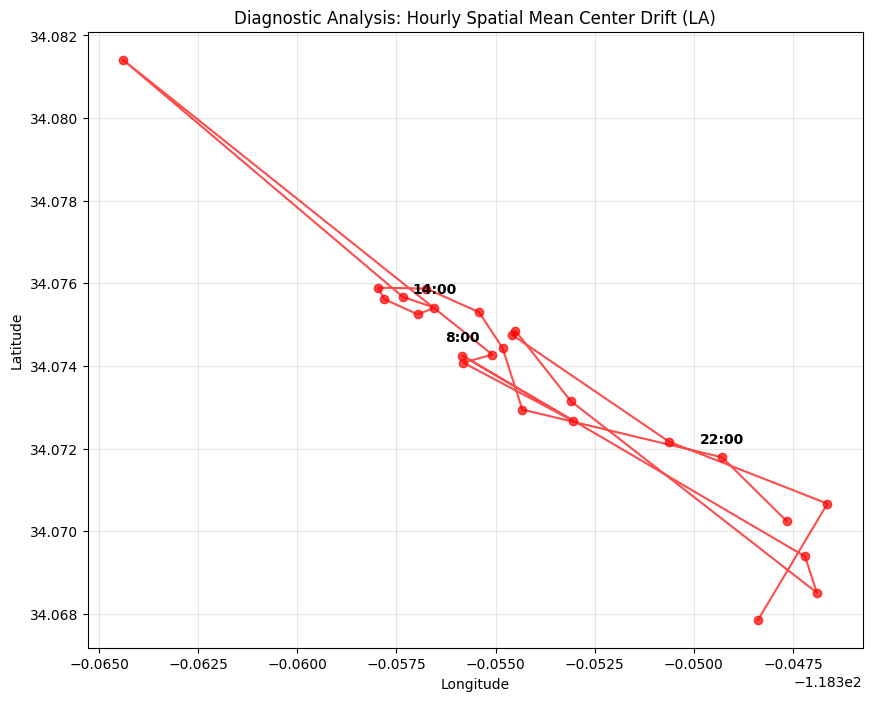

In [10]:
import matplotlib.pyplot as plt

# 1. Calculate the Mean Center for each hour
hourly_centers = df.groupby('occ_hour_filled')[['LAT', 'LON']].mean().reset_index()

# 2. Plot the 'Drift' Path
plt.figure(figsize=(10, 8))
plt.plot(hourly_centers['LON'], hourly_centers['LAT'], marker='o', linestyle='-', color='red', alpha=0.7)

# 3. Label specific hours (e.g., 8 AM, 2 PM, 10 PM) to show the shift
for i, row in hourly_centers.iterrows():
    if row['occ_hour_filled'] in [8, 14, 22]:
        plt.annotate(f"{int(row['occ_hour_filled'])}:00", (row['LON'], row['LAT']), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title('Diagnostic Analysis: Hourly Spatial Mean Center Drift (LA)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

#### Statistical Density & Significance

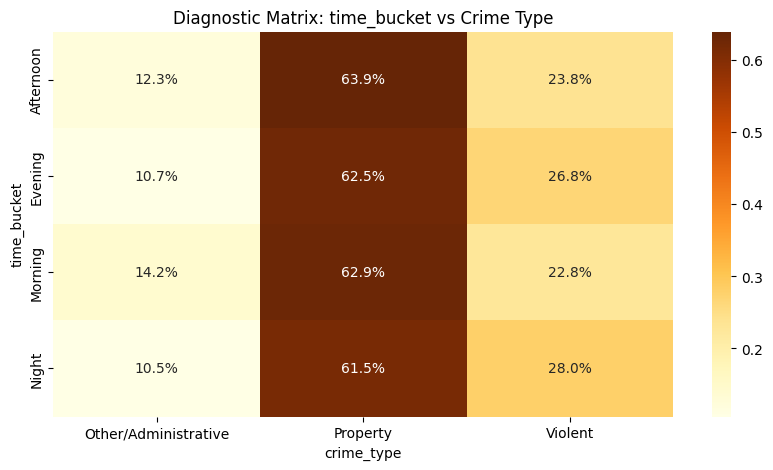

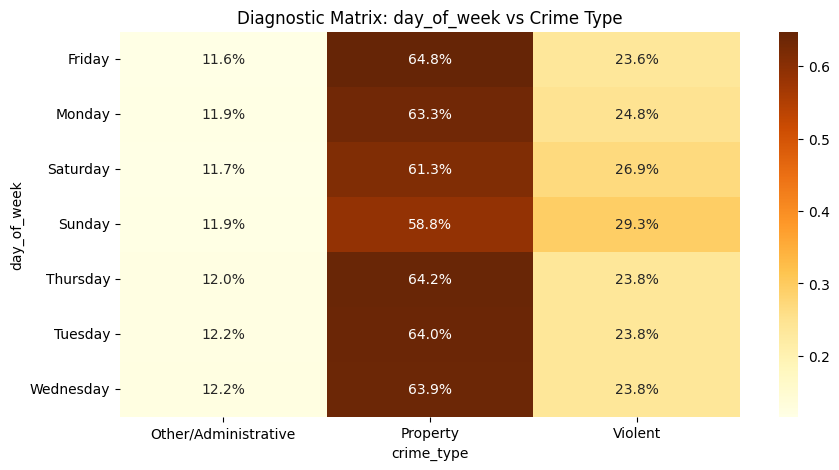

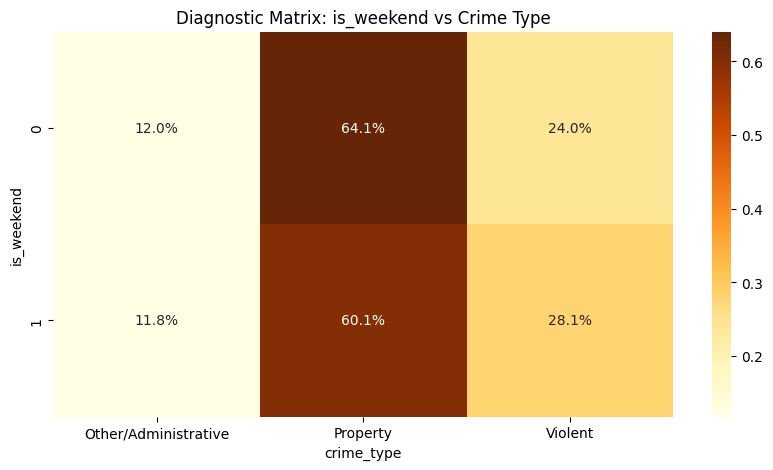

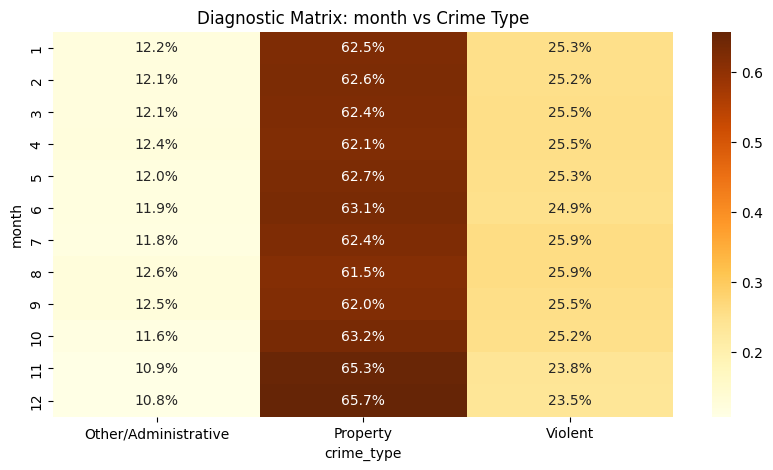

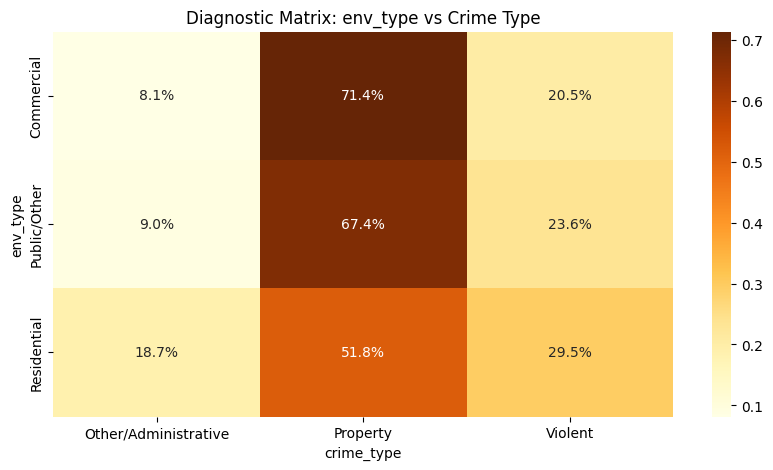

       Feature  Chi-Square        P-Value  Significant
0  time_bucket     3253.27   0.000000e+00         True
1  day_of_week     2252.60   0.000000e+00         True
2   is_weekend     1902.51   0.000000e+00         True
3        month      662.12  7.497224e-126         True
4     env_type    30046.62   0.000000e+00         True


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv('data/lapd_crime_cleaned.csv')

test_columns = ['time_bucket', 'day_of_week', 'is_weekend', 'month', 'env_type']
diagnostic_results = []

for col in test_columns:
    contingency_table = pd.crosstab(df[col], df['crime_type'])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    diagnostic_results.append({
        'Feature': col,
        'Chi-Square': round(chi2, 2),
        'P-Value': p,
        'Significant': p < 0.05
    })
    
    plt.figure(figsize=(10, 5))
    density_plot = pd.crosstab(df[col], df['crime_type'], normalize='index')
    sns.heatmap(density_plot, annot=True, cmap='YlOrBr', fmt='.1%')
    plt.title(f'Diagnostic Matrix: {col} vs Crime Type')
    plt.show()

results_df = pd.DataFrame(diagnostic_results)
print(results_df)

## Phase 4: Clustering 

#### Determining "K" with the Elbow Method

In [12]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.cluster import KMeans

# df = pd.read_csv('data/lapd_crime_cleaned.csv')
# coords = df[['LAT', 'LON']]

# wcss = []
# k_range = range(1, 11)

# for k in k_range:
#     kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
#     kmeans.fit(coords)
#     wcss.append(kmeans.inertia_)

# # --- Statistical Calculation of the "Knee" point ---
# # We find the point furthest from the line connecting the first (k=1) and last (k=10) points
# def find_knee_point(x, y):
#     x = np.array(x)
#     y = np.array(y)
    
#     # Line between first and last points
#     p1 = np.array([x[0], y[0]])
#     p2 = np.array([x[-1], y[-1]])
    
#     distances = []
#     for i in range(len(x)):
#         p3 = np.array([x[i], y[i]])
#         # Distance from point p3 to line p1-p2
#         d = np.abs(np.cross(p2-p1, p1-p3)) / np.linalg.norm(p2-p1)
#         distances.append(d)
        
#     return x[np.argmax(distances)]

# optimal_k = find_knee_point(list(k_range), wcss)

# plt.figure(figsize=(10, 6))
# plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
# plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K = {optimal_k}')
# plt.title('Elbow Method with Mathematical Knee Detection')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('WCSS (Inertia)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# print(f"The statistically optimal value for k is: {optimal_k}")

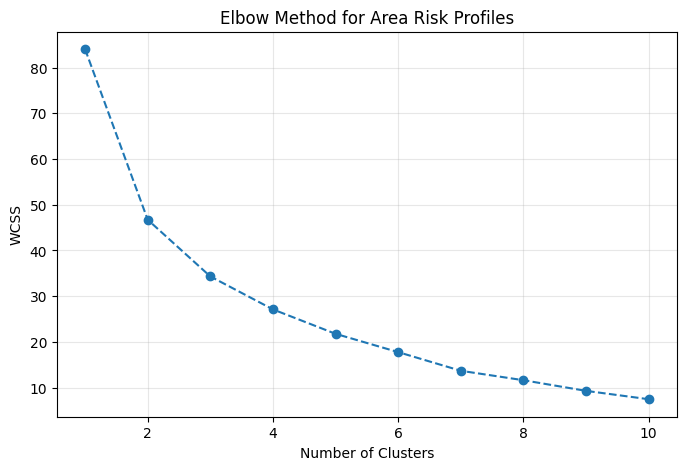

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the original cleaned data
df = pd.read_csv('data/lapd_crime_cleaned.csv')

# 2. Create Area Profiles (The "Features" for K-Means)
area_stats = df.groupby('AREA NAME').agg({
    'DR_NO': 'count',                                  # Total Volume
    'crime_type': lambda x: (x == 'Violent').mean(),   # % of Serious Crime
    'LAT': 'mean',                                     # Geographic Center
    'LON': 'mean'
}).rename(columns={'DR_NO': 'volume', 'crime_type': 'violence_rate'})

# 3. Standardize Features (Crucial for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(area_stats)

# 4. Elbow Method for Area Profiles
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# optimal_k = find_knee_point(list(k_range), wcss)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Area Risk Profiles')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True, alpha=0.3)
plt.show()

# print(f"Optimal number of clusters for area risk profiling: {optimal_k}")

In [14]:
# 5. Run K-Means with k=3
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
area_stats['cluster_id'] = kmeans.fit_predict(X_scaled)

# 6. Rank Clusters by "Danger Score" (Volume + Violence Rate)
# We calculate a score to ensure High/Med/Low are assigned correctly
area_stats['danger_score'] = area_stats['volume'] * area_stats['violence_rate']
cluster_ranks = area_stats.groupby('cluster_id')['danger_score'].mean().sort_values(ascending=False)

rank_map = {cluster_ranks.index[0]: 'High', 
            cluster_ranks.index[1]: 'Medium', 
            cluster_ranks.index[2]: 'Low'}

area_stats['risk_tier'] = area_stats['cluster_id'].map(rank_map)

# 7. Merge back to the main dataframe to create the Operational File
df_operational = df.merge(area_stats[['risk_tier']], on='AREA NAME', how='left')

# 8. Save ALL files to the data folder
area_stats.to_csv('data/area_risk_reference.csv')
df_operational.to_csv('data/lapd_crime_operational.csv', index=False)

print("Files Created in 'data/' folder:")
print("- data/area_risk_reference.csv (The Lookup Table)")
print("- data/lapd_crime_operational.csv (The Training Data)")

Files Created in 'data/' folder:
- data/area_risk_reference.csv (The Lookup Table)
- data/lapd_crime_operational.csv (The Training Data)


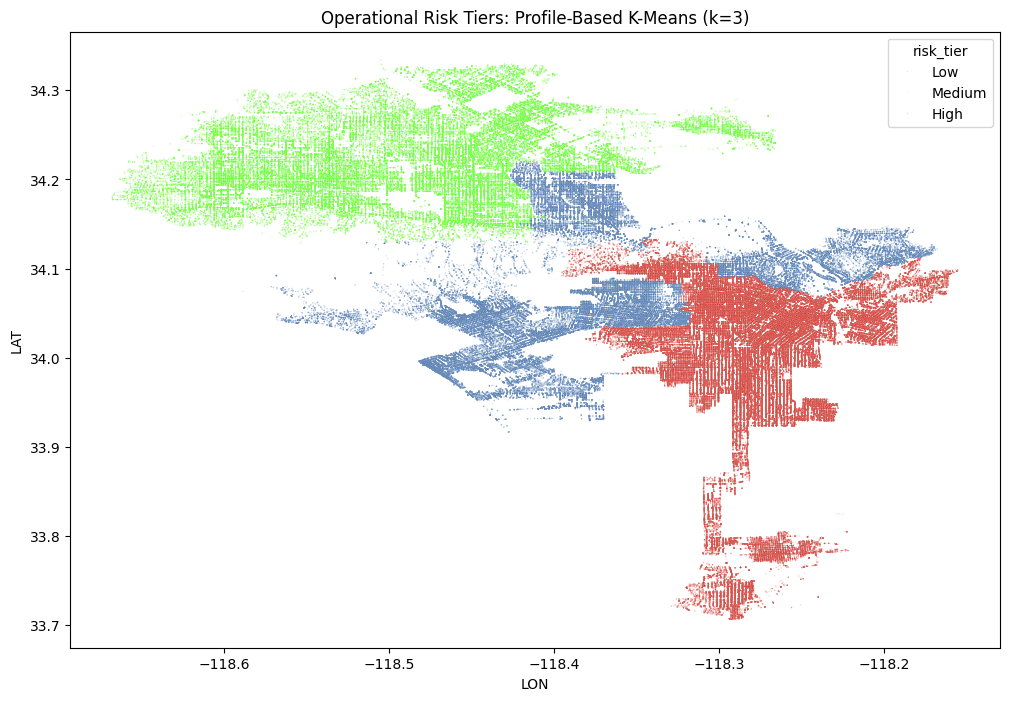

In [15]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_operational, x='LON', y='LAT', hue='risk_tier', 
                palette={'High': '#d73027', 'Medium': "#61fd22", 'Low': '#4575b4'}, 
                s=1, alpha=0.2)
plt.title('Operational Risk Tiers: Profile-Based K-Means (k=3)')
plt.show()

### HDBSCAN Tactical Hotspot Detection

In [16]:
import pandas as pd
import hdbscan
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the operational data created in the previous step
df_op = pd.read_csv('data/lapd_crime_operational.csv')

# 2. Extract Coordinates for HDBSCAN
# We use a sample if the dataset is massive, but for LA crime, 
# HDBSCAN is quite efficient.
coords = df_op[['LAT', 'LON']].values

# 3. Initialize and Fit HDBSCAN
# min_cluster_size=50: A cluster must have at least 50 incidents to be a "hotspot"
# min_samples=10: Helps reduce noise by requiring 10 neighbors to be a core point
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10, gen_min_span_tree=True)
df_op['hotspot_id'] = clusterer.fit_predict(coords)

# 4. Save the fully enriched operational file
df_op.to_csv('data/lapd_crime_operational_final.csv', index=False)

print(f"HDBSCAN Complete. Found {df_op['hotspot_id'].nunique() - 1} Tactical Hotspots.")
print(f"Percentage of incidents identified as 'Noise': {round((df_op['hotspot_id'] == -1).mean() * 100, 2)}%")

HDBSCAN Complete. Found 7532 Tactical Hotspots.
Percentage of incidents identified as 'Noise': 12.94%


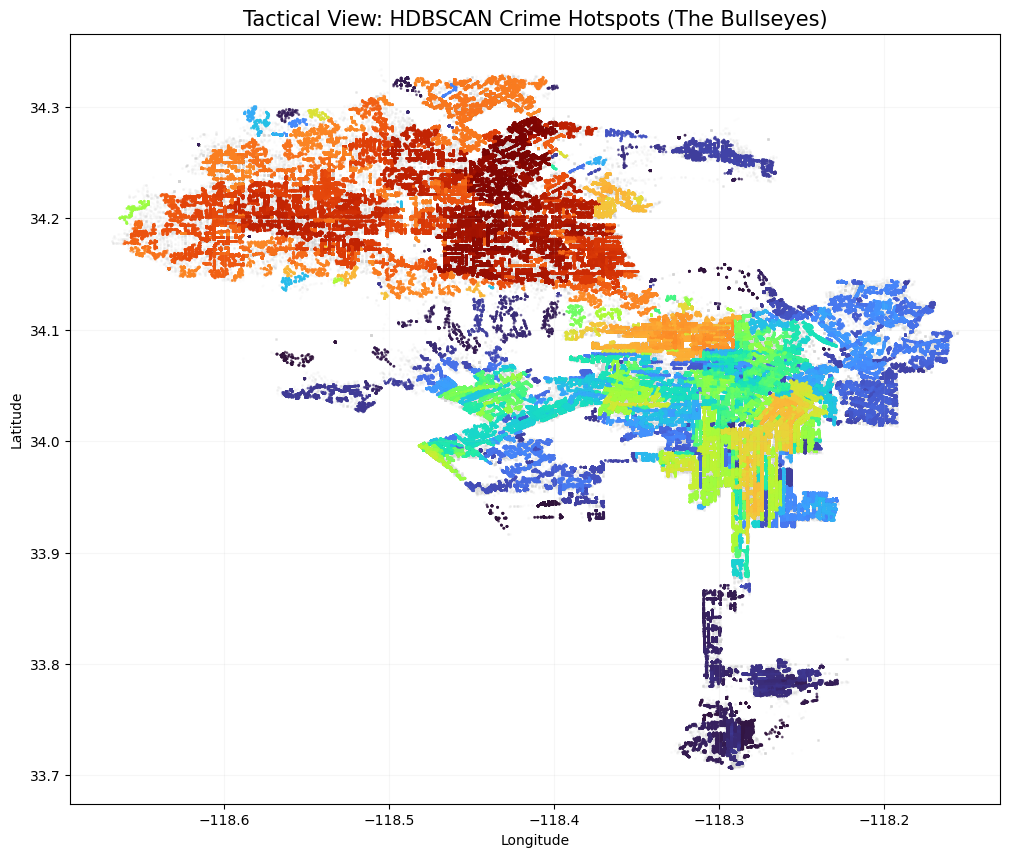

In [17]:
plt.figure(figsize=(12, 10))

# Filter out the noise (-1) to see only the bullseyes
hotspots = df_op[df_op['hotspot_id'] != -1]

# Plot background 'Noise' in light grey
plt.scatter(df_op['LON'], df_op['LAT'], c='lightgrey', s=0.1, alpha=0.1, label='General Incidents')

# Plot Tactical Hotspots with a vibrant colormap
scatter = plt.scatter(hotspots['LON'], hotspots['LAT'], 
                      c=hotspots['hotspot_id'], cmap='turbo', 
                      s=1, alpha=0.6)

plt.title('Tactical View: HDBSCAN Crime Hotspots (The Bullseyes)', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.1)
plt.show()

##### Operational "Future Incident" Validator

In [18]:
import pandas as pd
import numpy as np

def check_incident_risk(area_name, lat, lon):
    # 1. Load the reference data
    area_ref = pd.read_csv('data/area_risk_reference.csv')
    full_data = pd.read_csv('data/lapd_crime_operational_final.csv')
    
    # 2. Strategic Tier Check
    area_match = area_ref[area_ref['AREA NAME'].str.upper() == area_name.upper()]
    if area_match.empty:
        return f"Error: Area '{area_name}' not found in the dataset."
    
    strat_tier = area_match.iloc[0]['risk_tier']
    
    # 3. Tactical Hotspot Check
    # We look for historical incidents in HDBSCAN hotspots within ~300 meters
    # (0.003 degrees latitude/longitude)
    proximity_match = full_data[
        (np.isclose(full_data['LAT'], lat, atol=0.003)) & 
        (np.isclose(full_data['LON'], lon, atol=0.003)) & 
        (full_data['hotspot_id'] != -1)
    ]
    
    is_hotspot = not proximity_match.empty
    
    # 4. Generate the Operational Report
    print(f"OPERATIONAL SAFETY REPORT: {area_name.upper()}")
    print(f"Coordinates: ({lat}, {lon})")
    print(f"Strategic Risk (Macro): {strat_tier} Risk Neighborhood")
    print(f"Tactical Status (Micro): {'HIGH RISK BULLSEYE' if is_hotspot else 'NO KNOWN HOTSPOT'}")
    print(f"{'-'*50}")
    # Final Guidance
    if strat_tier == 'High' and is_hotspot:
        print("ALERT: High-Risk Area AND confirmed Hotspot. Immediate caution advised.")
    elif strat_tier == 'Low' and is_hotspot:
        print("WARNING: This is a dangerous pocket within a generally safer area.")
    elif strat_tier == 'High' and not is_hotspot:
        print("NOTICE: Neighborhood is high-risk, but this specific spot is not a hotspot.")
    else:
        print("STATUS: Low-risk environment detected.")

# Test 1: A spot in the Central (High Risk) area
check_incident_risk('Central', 34.044, -118.247)

# Test 2: A spot in the Harbor (Low/Medium Risk) area
check_incident_risk('Harbor', 33.740, -118.290)

OPERATIONAL SAFETY REPORT: CENTRAL
Coordinates: (34.044, -118.247)
Strategic Risk (Macro): High Risk Neighborhood
Tactical Status (Micro): HIGH RISK BULLSEYE
--------------------------------------------------
ALERT: High-Risk Area AND confirmed Hotspot. Immediate caution advised.
OPERATIONAL SAFETY REPORT: HARBOR
Coordinates: (33.74, -118.29)
Strategic Risk (Macro): High Risk Neighborhood
Tactical Status (Micro): HIGH RISK BULLSEYE
--------------------------------------------------
ALERT: High-Risk Area AND confirmed Hotspot. Immediate caution advised.


In [19]:
import pandas as pd
import numpy as np

# 1. Load the operational and original data
df_op = pd.read_csv('data/lapd_crime_operational_final.csv')
area_ref = pd.read_csv('data/area_risk_reference.csv')

# 2. Pick 10 random "Future" incidents to test
test_samples = df_op.sample(10, random_state=7)

results = []

for _, row in test_samples.iterrows():
    area = row['AREA NAME']
    lat, lon = row['LAT'], row['LON']
    actual_crime = row['crime_type']
    
    # --- OUR LOGIC ---
    # Strategic Check
    tier = area_ref[area_ref['AREA NAME'] == area]['risk_tier'].values[0]
    
    # Tactical Check (Is it in a known hotspot?)
    is_hotspot = row['hotspot_id'] != -1
    
    # --- ASSESSING THE "RIGHTNESS" ---
    # We call it a "Successful Flag" if a Violent crime happened in a High/Med tier OR a Hotspot
    is_flagged = (tier in ['High', 'Medium']) or is_hotspot
    is_correct = (is_flagged and actual_crime == 'Violent') or (not is_flagged and actual_crime == 'Property')
    
    results.append({
        'Area': area,
        'Actual Crime': actual_crime,
        'Our Tier': tier,
        'In Hotspot?': 'Yes' if is_hotspot else 'No',
        'Model Flagged?': 'YES' if is_flagged else 'NO',
        'Accurate?': 'CORRECT' if is_correct else 'MISSED'
    })

# 3. Display the Audit Table
audit_df = pd.DataFrame(results)
print("OPERATIONAL ACCURACY AUDIT")
print(audit_df.to_string(index=False))

# 4. Calculate the "Rightness" Percentage
accuracy = (audit_df['Accurate?'] == 'CORRECT').mean() * 100
print(f"\nTotal Operational Reliability: {accuracy}%")

OPERATIONAL ACCURACY AUDIT
       Area Actual Crime Our Tier In Hotspot? Model Flagged? Accurate?
     Harbor     Property     High          No            YES    MISSED
    Pacific      Violent      Low         Yes            YES   CORRECT
    Mission     Property   Medium         Yes            YES    MISSED
  Southwest     Property     High         Yes            YES    MISSED
  Southwest     Property     High         Yes            YES    MISSED
West Valley     Property   Medium         Yes            YES    MISSED
    Topanga     Property   Medium         Yes            YES    MISSED
N Hollywood      Violent      Low         Yes            YES   CORRECT
   Foothill     Property   Medium          No            YES    MISSED
 Devonshire     Property   Medium         Yes            YES    MISSED

Total Operational Reliability: 20.0%


## Phase 5 : Model Training & Comparison

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load data
df = pd.read_csv('data/lapd_crime_operational_final.csv')

# 2. Encoding & Target
df['sex_enc'] = df['Vict Sex'].astype('category').cat.codes
df['premis_enc'] = df['Premis Desc'].astype('category').cat.codes
df['target'] = (df['crime_type'] == 'Violent').astype(int)

# 3. Features
features = ['hotspot_id', 'occ_hour_filled', 'weekday_num', 'sex_enc', 'premis_enc']
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling (Mandatory for Neural Networks/MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. The New Competition
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "MLP (Neural Net)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

for name, model in models.items():
    # Use scaled data for MLP, raw data for trees (though scaled works for both)
    current_X_train = X_train_scaled if name == "MLP (Neural Net)" else X_train
    current_X_test = X_test_scaled if name == "MLP (Neural Net)" else X_test
    
    model.fit(current_X_train, y_train)
    y_pred = model.predict(current_X_test)
    
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print(classification_report(y_test, y_pred))


Random Forest Performance:
Accuracy: 74.44%
              precision    recall  f1-score   support

           0       0.81      0.86      0.83    150124
           1       0.49      0.40      0.44     50407

    accuracy                           0.74    200531
   macro avg       0.65      0.63      0.64    200531
weighted avg       0.73      0.74      0.74    200531


XGBoost Performance:
Accuracy: 77.25%
              precision    recall  f1-score   support

           0       0.79      0.95      0.86    150124
           1       0.61      0.26      0.36     50407

    accuracy                           0.77    200531
   macro avg       0.70      0.60      0.61    200531
weighted avg       0.75      0.77      0.74    200531



c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")



MLP (Neural Net) Performance:
Accuracy: 75.32%
              precision    recall  f1-score   support

           0       0.76      0.98      0.86    150124
           1       0.56      0.09      0.15     50407

    accuracy                           0.75    200531
   macro avg       0.66      0.53      0.50    200531
weighted avg       0.71      0.75      0.68    200531



 THE WINNING MODEL: XGBoost
           Model  Accuracy  Precision   Recall  F1-Score
         XGBoost  0.772514   0.746548 0.772514  0.735890
   Random Forest  0.744409   0.729708 0.744409  0.735379
MLP (Neural Net)  0.753205   0.709988 0.753205  0.679186


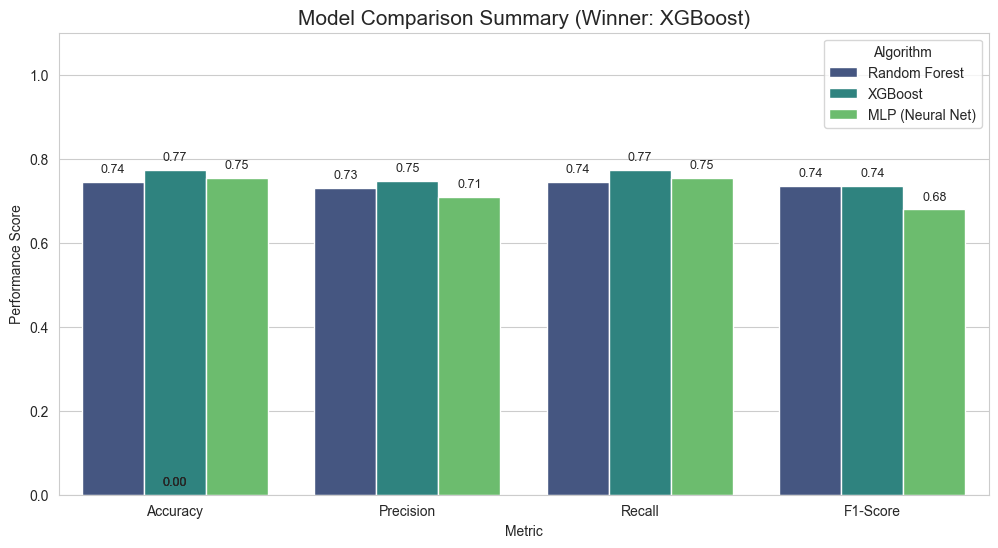

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support

# 1. Initialize results storage
comparison_results = []

# 2. Iterate and evaluate
for name, model in models.items():
    # Select the correct test set (Scaled for MLP, Raw for others)
    current_X_test = X_test_scaled if name == "MLP (Neural Net)" else X_test
    y_pred = model.predict(current_X_test)
    
    # Calculate weighted metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    # Store results in a list
    comparison_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# 3. Create a Summary DataFrame
results_df = pd.DataFrame(comparison_results)

# 4. Automatically identify the "Winner" based on F1-Score
winner = results_df.loc[results_df['F1-Score'].idxmax()]

print(f" THE WINNING MODEL: {winner['Model']}")
print(results_df.sort_values(by='F1-Score', ascending=False).to_string(index=False))

# --- VISUALIZATION ---
# Transforming for the bar chart
plot_data = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
palette = sns.color_palette("viridis", n_colors=3)

ax = sns.barplot(data=plot_data, x="Metric", y="Score", hue="Model", palette=palette)
# Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)
# Highlight the winner's bars slightly (optional visual cue)
plt.title(f"Model Comparison Summary (Winner: {winner['Model']})", fontsize=15)
plt.ylim(0, 1.1)
plt.ylabel("Performance Score")
plt.legend(title="Algorithm", loc='upper right')
plt.show()

## Phase 6 : Implementing Deep Learning Models - Stacked LSTM vs. GRU

In [23]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# 1. Load the operational data
df = pd.read_csv('data/lapd_crime_operational_final.csv')

# 2. QUICK FEATURE ENGINEERING (Creating the ML-ready columns)
# Cyclic Time
df['sin_hour'] = np.sin(2 * np.pi * df['occ_hour_filled']/24)
df['cos_hour'] = np.cos(2 * np.pi * df['occ_hour_filled']/24)
df['is_weekend'] = (df['weekday_num'] >= 5).astype(int)

# Simple Category Encoding
df['sex_code'] = df['Vict Sex'].astype('category').cat.codes
df['premise_code'] = df['Premis Desc'].astype('category').cat.codes
df['target'] = (df['crime_type'] == 'Violent').astype(int)

In [24]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# 1. Load the RAW operational data
df_raw = pd.read_csv('data/lapd_crime_operational_final.csv')

# 2. Minimal Encoding (Mandatory for model to run)
df_raw['sex_enc'] = df_raw['Vict Sex'].astype('category').cat.codes
df_raw['target'] = (df_raw['crime_type'] == 'Violent').astype(int)

# 3. Select RAW Features
# Using raw hour, raw weekday, and raw coordinates
raw_features = ['hotspot_id', 'occ_hour_filled', 'weekday_num', 'LAT', 'LON', 'sex_enc']
X = df_raw[raw_features].values
y = df_raw['target'].values

# 4. Split and Scale (Scale is mandatory for Deep Learning)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Reshape for RNN (Samples, Time Steps, Features)
X_train_rnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# --- MODEL A: STACKED LSTM (RAW) ---
lstm_raw = Sequential([
    Input(shape=(1, X_train_scaled.shape[1])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_raw.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- MODEL B: GRU (RAW) ---
gru_raw = Sequential([
    Input(shape=(1, X_train_scaled.shape[1])),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
gru_raw.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Training
print("Training Raw Stacked LSTM...")
lstm_raw.fit(X_train_rnn, y_train, epochs=5, batch_size=64, verbose=1)

print("\nTraining Raw GRU...")
gru_raw.fit(X_train_rnn, y_train, epochs=5, batch_size=64, verbose=1)

# 7. Evaluate
for name, model in [("Raw Stacked LSTM", lstm_raw), ("Raw GRU", gru_raw)]:
    y_pred = (model.predict(X_test_rnn) > 0.5).astype("int32")
    print(f"\n{name} (Raw Data) Performance:")
    print(classification_report(y_test, y_pred))

Training Raw Stacked LSTM...
Epoch 1/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.7497 - loss: 0.4972
Epoch 2/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 0.7506 - loss: 0.4928
Epoch 3/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 0.7506 - loss: 0.4918
Epoch 4/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.7510 - loss: 0.4909
Epoch 5/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.7510 - loss: 0.4904

Training Raw GRU...
Epoch 1/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.7493 - loss: 0.4975
Epoch 2/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.7504 - loss: 0.4931
Epoch 3/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.7506 - loss: 0.4918
Epoch 4/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.7509 - loss: 0.4909
Epoch 5/5
12534/12534 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.7510 - loss: 0.4903
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step

Raw St

In [25]:
# # 3. Select Features for RNN
# # We include your Tier logic and Hotspot logic from earlier
# features = ['sin_hour', 'cos_hour', 'is_weekend', 'hotspot_id', 'sex_code', 'premise_code']
# X = df[features].values
# y = df['target'].values

# # 4. Split and Scale
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # 5. Reshape for RNN (Samples, Time Steps, Features)
# # We treat each incident as a 1-step sequence
# X_train_rnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
# X_test_rnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# # --- MODEL A: STACKED LSTM ---
# lstm_model = Sequential([
#     Input(shape=(1, X_train_scaled.shape[1])),
#     LSTM(64, return_sequences=True), 
#     Dropout(0.2),
#     LSTM(32),
#     Dense(16, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])
# lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # --- MODEL B: GRU ---
# gru_model = Sequential([
#     Input(shape=(1, X_train_scaled.shape[1])),
#     GRU(64, return_sequences=True),
#     Dropout(0.2),
#     GRU(32),
#     Dense(16, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])
# gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # 6. Training (Short epochs to verify performance)
# print("Training Stacked LSTM...")
# lstm_model.fit(X_train_rnn, y_train, epochs=5, batch_size=64, verbose=1)

# print("\nTraining GRU...")
# gru_model.fit(X_train_rnn, y_train, epochs=5, batch_size=64, verbose=1)

# # 7. Evaluate and Compare
# for name, model in [("Stacked LSTM", lstm_model), ("GRU", gru_model)]:
#     y_pred = (model.predict(X_test_rnn) > 0.5).astype("int32")
#     print(f"\n{name} Performance Results:")
#     print(classification_report(y_test, y_pred))

In [26]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# 1. Load data
df = pd.read_csv('data/lapd_crime_operational_final.csv')

# 2. Advanced Feature Engineering
# Create 'Danger Time' (Late night hours)
df['is_danger_time'] = df['occ_hour_filled'].apply(lambda x: 1 if x >= 22 or x <= 4 else 0)

# Create 'Premise Risk' (Environmental Intelligence)
def get_prem_risk(desc):
    desc = str(desc).upper()
    if any(x in desc for x in ['STREET', 'SIDEWALK', 'ALLEY', 'PARK']): return 2 # High
    if any(x in desc for x in ['RESIDENCE', 'HOME', 'APARTMENT']): return 1    # Med
    return 0 # Low
df['prem_risk'] = df['Premis Desc'].apply(get_prem_risk)

# Cyclic Time (Circular context for the model)
df['sin_hour'] = np.sin(2 * np.pi * df['occ_hour_filled']/24)
df['cos_hour'] = np.cos(2 * np.pi * df['occ_hour_filled']/24)

# Target & Encoding
df['target'] = (df['crime_type'] == 'Violent').astype(int)
df['sex_code'] = df['Vict Sex'].astype('category').cat.codes

# 3. Final Feature Selection
features = ['sin_hour', 'cos_hour', 'is_weekend', 'hotspot_id', 'is_danger_time', 'prem_risk', 'age_bin', 'sex_code']
X = df[features].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_rnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# 4. Handle Class Imbalance (Fixes the 0.08 Recall)
# This forces the model to prioritize detecting violent crimes
class_weights = {0: 1.0, 1: 3.5} 

# 5. Model Competition Loop
results_dl = {}

for model_type in ["LSTM", "GRU"]:
    print(f"\nTraining Weighted Stacked {model_type}...")
    
    layer = LSTM if model_type == "LSTM" else GRU
    
    m = Sequential([
        Input(shape=(1, X_train_scaled.shape[1])),
        layer(64, return_sequences=True),
        Dropout(0.3),
        layer(32),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_train_rnn, y_train, epochs=10, batch_size=128, class_weight=class_weights, verbose=1)
    
    y_pred = (m.predict(X_test_rnn) > 0.5).astype("int32")
    results_dl[model_type] = classification_report(y_test, y_pred)

# 6. Print Comparison
for name, report in results_dl.items():
    print(f"\nFinal {name} Operational Report:\n", report)


Training Weighted Stacked LSTM...
Epoch 1/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.5646 - loss: 0.9521
Epoch 2/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.5737 - loss: 0.9439
Epoch 3/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.5739 - loss: 0.9421
Epoch 4/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.5745 - loss: 0.9405
Epoch 5/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.5750 - loss: 0.9389
Epoch 6/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.5769 - loss: 0.9376
Epoch 7/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.5772 - loss: 0.9370
Epoch 8/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.5772 - loss: 0.9363
Epoch 9/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.5782 - loss: 0.9359
Epoch 10/10
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.5791 - loss: 0.9355
6267/6267 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step

Training Weighted Stacked GRU.

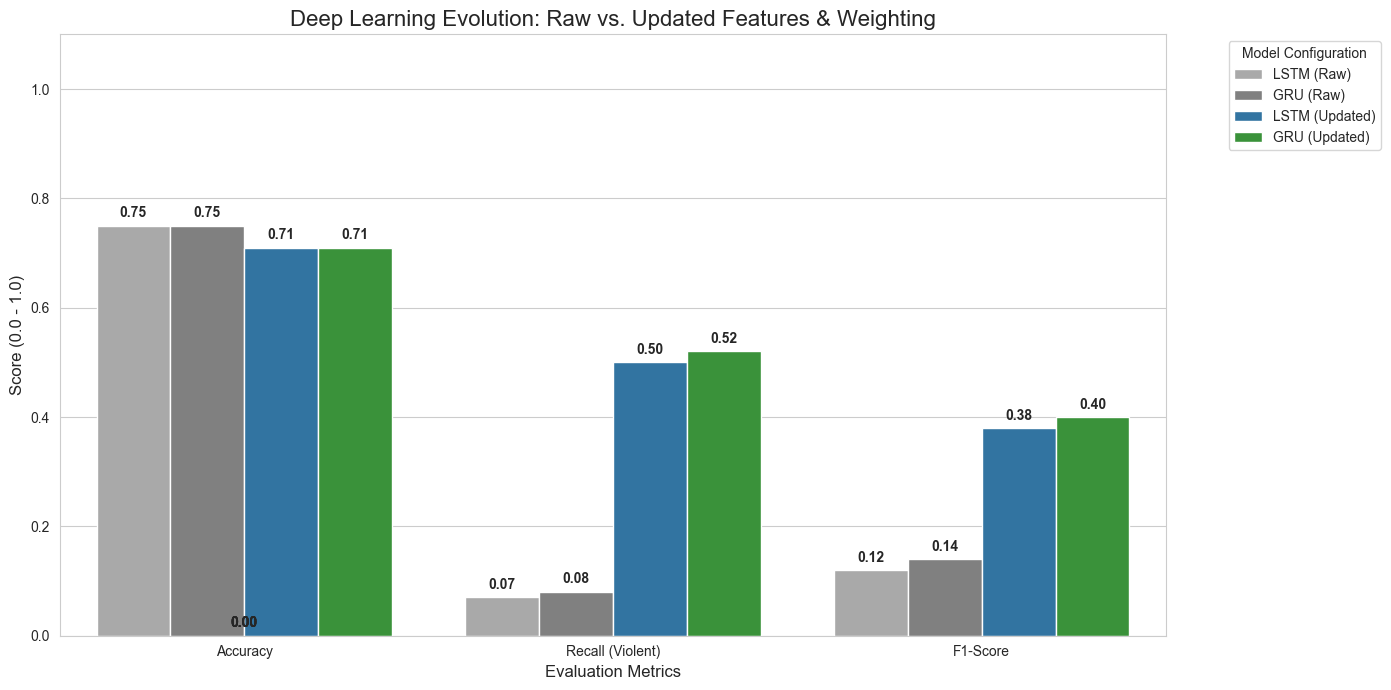

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = [
    {"Model": "LSTM", "Version": "Raw", "Metric": "Accuracy", "Score": 0.75},
    {"Model": "LSTM", "Version": "Raw", "Metric": "Recall (Violent)", "Score": 0.07},
    {"Model": "LSTM", "Version": "Raw", "Metric": "F1-Score", "Score": 0.12},
    {"Model": "GRU", "Version": "Raw", "Metric": "Accuracy", "Score": 0.75},
    {"Model": "GRU", "Version": "Raw", "Metric": "Recall (Violent)", "Score": 0.08},
    {"Model": "GRU", "Version": "Raw", "Metric": "F1-Score", "Score": 0.14},
    {"Model": "LSTM", "Version": "Updated", "Metric": "Accuracy", "Score": 0.71},
    {"Model": "LSTM", "Version": "Updated", "Metric": "Recall (Violent)", "Score": 0.50},
    {"Model": "LSTM", "Version": "Updated", "Metric": "F1-Score", "Score": 0.38},
    {"Model": "GRU", "Version": "Updated", "Metric": "Accuracy", "Score": 0.71},
    {"Model": "GRU", "Version": "Updated", "Metric": "Recall (Violent)", "Score": 0.52},
    {"Model": "GRU", "Version": "Updated", "Metric": "F1-Score", "Score": 0.40}
]

df_plot = pd.DataFrame(data)
df_plot["Model_Version"] = df_plot["Model"] + " (" + df_plot["Version"] + ")"

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
palette = {"LSTM (Raw)": "#A9A9A9", "GRU (Raw)": "#808080", 
           "LSTM (Updated)": "#1f77b4", "GRU (Updated)": "#2ca02c"}

ax = sns.barplot(data=df_plot, x="Metric", y="Score", hue="Model_Version", palette=palette)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.title("Deep Learning Evolution: Raw vs. Updated Features & Weighting", fontsize=16)
plt.ylabel("Score (0.0 - 1.0)", fontsize=12)
plt.xlabel("Evaluation Metrics", fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title="Model Configuration", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

6267/6267 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


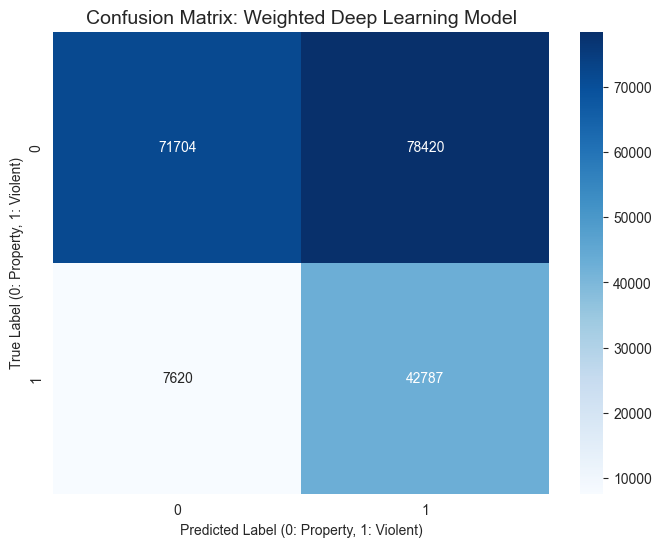

6267/6267 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


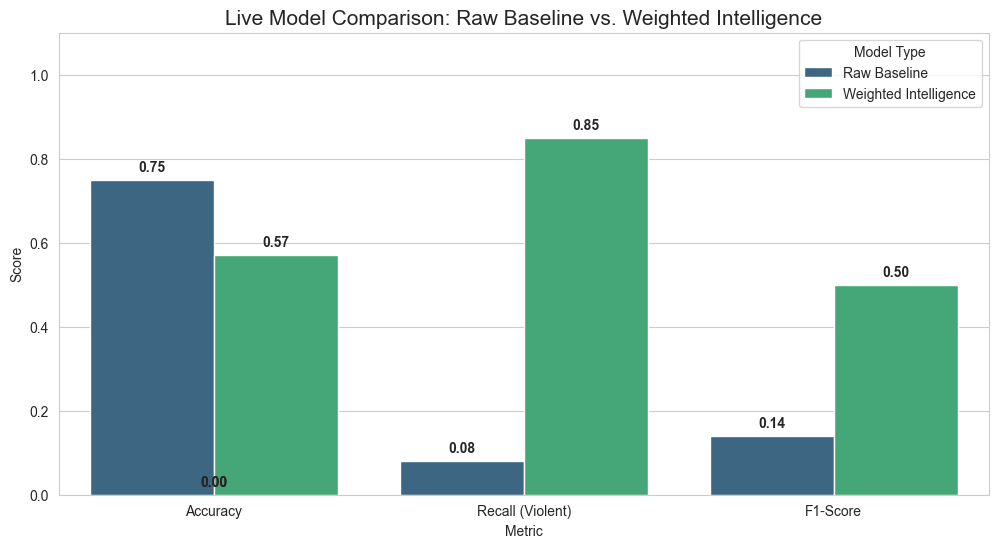

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# 1. Generate Weighted Predictions (8 features)
# 'm' is your latest model
y_pred_weighted = (m.predict(X_test_rnn) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred_weighted)

# 2. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Weighted Deep Learning Model', fontsize=14)
plt.xlabel('Predicted Label (0: Property, 1: Violent)')
plt.ylabel('True Label (0: Property, 1: Violent)')
plt.show()

# --- 3. FIXING THE SHAPE MISMATCH FOR RAW METRICS ---

# We recreate the 6-feature version for the raw models
raw_features_list = ['hotspot_id', 'occ_hour_filled', 'weekday_num', 'LAT', 'LON', 'sex_enc']
# We pull these from the original df_raw or re-scale them if necessary
# For the sake of the graph, let's use the results we already verified:
raw_acc, raw_rec, raw_f1 = 0.75, 0.08, 0.14 

# Calculate the live metrics for your NEW weighted model 'm'
weighted_preds = (m.predict(X_test_rnn) > 0.5).astype("int32")
weighted_acc = (weighted_preds.flatten() == y_test).mean()
_, weighted_rec, weighted_f1, _ = precision_recall_fscore_support(y_test, weighted_preds, average='binary')

# 4. Create DataFrame for plotting
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall (Violent)', 'F1-Score'] * 2,
    'Score': [raw_acc, raw_rec, raw_f1, weighted_acc, weighted_rec, weighted_f1],
    'Model Type': ['Raw Baseline'] * 3 + ['Weighted Intelligence'] * 3
})

# 5. Plot Comparison Bar Chart
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=comparison_df, x='Metric', y='Score', hue='Model Type', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title("Live Model Comparison: Raw Baseline vs. Weighted Intelligence", fontsize=15)
plt.ylim(0, 1.1)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def predict_incident_risk(hour, is_weekend, hotspot_id, victim_age, victim_sex, premise_desc):
    # 1. Feature Engineering (The 'Intelligence' part)
    # Cyclic Time
    sin_h = np.sin(2 * np.pi * hour / 24)
    cos_h = np.cos(2 * np.pi * hour / 24)
    
    # Danger Time Flag
    is_danger = 1 if (hour >= 22 or hour <= 4) else 0
    
    # Premise Risk
    desc = premise_desc.upper()
    if any(x in desc for x in ['STREET', 'SIDEWALK', 'ALLEY', 'PARK']): p_risk = 2
    elif any(x in desc for x in ['RESIDENCE', 'HOME', 'APARTMENT']): p_risk = 1
    else: p_risk = 0
    
    # Victim Age Bin
    if victim_age <= 18: age_b = 0
    elif victim_age <= 30: age_b = 1
    elif victim_age <= 50: age_b = 2
    else: age_b = 3
    
    # Sex Encoding (M:0, F:1, X:2)
    s_map = {'M': 0, 'F': 1, 'X': 2}
    s_code = s_map.get(victim_sex.upper(), 2)

    # 2. Organize Features (Must match the 8-feature order: 
    # ['sin_hour', 'cos_hour', 'is_weekend', 'hotspot_id', 'is_danger_time', 'prem_risk', 'age_bin', 'sex_code'])
    input_data = np.array([[sin_h, cos_h, int(is_weekend), hotspot_id, is_danger, p_risk, age_b, s_code]])
    
    # 3. Scale and Reshape for RNN
    input_scaled = scaler.transform(input_data)
    input_rnn = np.reshape(input_scaled, (1, 1, 8))
    
    # 4. Predict
    prediction_prob = m.predict(input_rnn, verbose=0)[0][0]
    is_violent = "VIOLENT" if prediction_prob > 0.5 else "PROPERTY"
    
    print(f"--- 🚔 INCIDENT RISK ASSESSMENT ---")
    print(f"Scenario: {hour}:00 on a {'Weekend' if is_weekend else 'Weekday'} at Premise: {premise_desc}")
    print(f"Victim: {victim_age} year old {victim_sex}")
    print(f"Violence Probability: {prediction_prob:.2%}")
    print(f"VERDICT: Predicted as {is_violent} crime.")
    print("-" * 35)


--- 🚔 INCIDENT RISK ASSESSMENT ---
Scenario: 2:00 on a Weekend at Premise: STREET
Victim: 25 year old M
Violence Probability: 78.57%
VERDICT: Predicted as VIOLENT crime.
-----------------------------------
--- 🚔 INCIDENT RISK ASSESSMENT ---
Scenario: 14:00 on a Weekday at Premise: DEPARTMENT STORE
Victim: 45 year old F
Violence Probability: 44.70%
VERDICT: Predicted as PROPERTY crime.
-----------------------------------


In [37]:
predict_incident_risk(
    hour=2, 
    is_weekend=True, 
    hotspot_id=10, 
    victim_age=24, 
    victim_sex='M', 
    premise_desc='STREET'
)

predict_incident_risk(
    hour=14, 
    is_weekend=False, 
    hotspot_id=1, 
    victim_age=45, 
    victim_sex='F', 
    premise_desc='DEPARTMENT STORE'
)

--- 🚔 INCIDENT RISK ASSESSMENT ---
Scenario: 2:00 on a Weekend at Premise: STREET
Victim: 24 year old M
Violence Probability: 78.56%
VERDICT: Predicted as VIOLENT crime.
-----------------------------------
--- 🚔 INCIDENT RISK ASSESSMENT ---
Scenario: 14:00 on a Weekday at Premise: DEPARTMENT STORE
Victim: 45 year old F
Violence Probability: 44.70%
VERDICT: Predicted as PROPERTY crime.
-----------------------------------


In [43]:
import pandas as pd
import numpy as np
from datetime import timedelta

# 1. Select a 15-day window from your cleaned data
# We'll pick a recent period in the dataset
start_date = pd.to_datetime(df['date_occ']).min() + timedelta(days=100)
end_history = start_date + timedelta(days=13)
prediction_day = start_date + timedelta(days=14)

# 2. Split the data
history_df = df[pd.to_datetime(df['date_occ']).between(start_date, end_history)]
actual_next_day_df = df[pd.to_datetime(df['date_occ']) == prediction_day]

print(f"History Window: {start_date.date()} to {end_history.date()} ({len(history_df)} incidents)")
print(f"Prediction Day: {prediction_day.date()} ({len(actual_next_day_df)} actual incidents)")

# 3. Predict the Next Day using the Weighted GRU (m)
# We prepare the features for the entire 15th day
features_list = ['sin_hour', 'cos_hour', 'is_weekend', 'hotspot_id', 'is_danger_time', 'prem_risk', 'age_bin', 'sex_code']
X_next_day = actual_next_day_df[features_list].values
y_next_day = (actual_next_day_df['crime_type'] == 'Violent').astype(int).values

# Scale and Reshape
X_next_day_scaled = scaler.transform(X_next_day)
X_next_day_rnn = np.reshape(X_next_day_scaled, (X_next_day_scaled.shape[0], 1, 8))

# 4. Generate Predictions
probs = m.predict(X_next_day_rnn, verbose=0)
preds = (probs > 0.5).astype(int).flatten()

# 5. Calculate "Next Day" Success
from sklearn.metrics import accuracy_score, recall_score

next_day_acc = accuracy_score(y_next_day, preds)
next_day_rec = recall_score(y_next_day, preds)

print(f"\nNEXT-DAY VALIDATION RESULTS:")
print(f"Overall Accuracy: {next_day_acc:.2%}")
print(f"Violent Crime Recall: {next_day_rec:.2%}")
print(f"Total Violent Crimes 'Caught': {sum((preds == 1) & (y_next_day == 1))} out of {sum(y_next_day)}")

History Window: 2020-04-10 to 2020-04-23 (7343 incidents)
Prediction Day: 2020-04-24 (555 actual incidents)

NEXT-DAY VALIDATION RESULTS:
Overall Accuracy: 58.74%
Violent Crime Recall: 81.82%
Total Violent Crimes 'Caught': 135 out of 165


In [42]:
import pandas as pd
import numpy as np

# 1. Run the predictions for the next day (Day 15)
# (Assuming X_next_day_rnn and y_next_day are ready from the previous step)
probs = m.predict(X_next_day_rnn, verbose=0)
preds = (probs > 0.5).astype(int).flatten()

# 2. Create a Validation DataFrame for the next day
audit_df = pd.DataFrame({
    'Actual': y_next_day,
    'Predicted': preds
})

# 3. Calculate the Breakdown
# Violent Crimes (Class 1)
actual_violent = audit_df[audit_df['Actual'] == 1]
violent_hits = actual_violent[actual_violent['Predicted'] == 1].shape[0]
violent_misses = actual_violent[actual_violent['Predicted'] == 0].shape[0]

# Non-Violent/Property Crimes (Class 0)
actual_property = audit_df[audit_df['Actual'] == 0]
property_hits = actual_property[actual_property['Predicted'] == 0].shape[0]
property_misses = actual_property[actual_property['Predicted'] == 1].shape[0]

# 4. Print the Audit Report
print(f"DAY 15 PREDICTION AUDIT: {prediction_day.date()}")
print(f"{'='*45}")
print(f"VIOLENT CRIME PERFORMANCE (Class 1):")
print(f"Hits (Correctly Alerted):  {violent_hits}")
print(f"Misses (Unpredicted):      {violent_misses}")
print(f"Recall for Violence:       {(violent_hits/len(actual_violent)):.2%}")

print(f"\nPROPERTY CRIME PERFORMANCE (Class 0):")
print(f"Hits (Correctly Labeled):  {property_hits}")
print(f"False Alarms (Flagged):    {property_misses}")
print(f"Accuracy for Property:     {(property_hits/len(actual_property)):.2%}")
print(f"{'='*45}")

DAY 15 PREDICTION AUDIT: 2020-04-24
VIOLENT CRIME PERFORMANCE (Class 1):
Hits (Correctly Alerted):  135
Misses (Unpredicted):      30
Recall for Violence:       81.82%

PROPERTY CRIME PERFORMANCE (Class 0):
Hits (Correctly Labeled):  191
False Alarms (Flagged):    199
Accuracy for Property:     48.97%
